2026-07-01 - TOR choro/before-panel + N=6 setup

did: restored 06-25 pool clean, wrote the DGP patch, then F~N(mu,1)). demoed, not yet spent on a city. rebuilt TOR pre-patch. fixed predict_da_theta (theta5 restored). built the flat before panel: DGP truth 1+0.4*F1+0.2*F3 vs flat recovered. geography for 3 new CMAs: Ott 2045, Cal 1898 and QC 1317. Drafted EE exports

results:
- before panel: truth SD 0.447 (range -0.58 to 2.78), recovered SD 0 (Flat 9.60). this is rthe baseline the patch has to beat
- C3 reproduced (mean |cor| 0.726, F1/F2 clean ~0.85, F3 entangled 0.48 - known).
- ottawa bi-provincial (prefix 24,35).

lessons
- don't let a map imply structure the DGP lacks. iid rnorm factors = sprea not geography. eye-clustering is apophenia
- EE zip-as-asset is not a verified FeatureCollection (check feature count = DA count before referencing!)
- bi-provincial CMA (most interesting) -> filtering on DGUID, never province as it would halve the city.
- recovered RR 9.60 is a placeholder, read the flatness not the level.

parked
- EE exports not run (next time), but everything waits on it
- compute_da_mmt fixes 2+3 (reduced basis not cb_template; diag 5 not 4).
- DRAC ful

restore + reattach -> retype 4. clobber order: lib cache -> reattach stack -> load() pilot -> readRDS 06-25 (fixed fn_* land last) then retype build_crossbasis, make_Strata_A/B, fit_da_pca

In [ ]:
DRIVE <- "/content/drive/MyDrive/thesis/dlnm-pilot"

system(sprintf("cd /content && cp %s/r_library.tar.gz . && tar -xzf r_library.tar.gz", DRIVE))
.libPaths(c("/content/site-library", .libPaths()))
suppressPackageStartupMessages({
  library(dlnm); library(gnm); library(mixmeta); library(splines)
  library(sf); library(data.table); library(exactextractr); library(terra)
  library(ggplot2); library(viridis); library(lubridate); library(MASS)
})

system(sprintf("cd /content && cp %s/saves_pilot_2026-06-03.tar.gz . && tar -xzf saves_pilot_2026-06-03.tar.gz", DRIVE))
load("/content/saves/pilot_session.RData")

system(sprintf("cd /content && cp %s/saves_eod_2026-06-25.tar.gz . && tar -xzf saves_eod_2026-06-25.tar.gz", DRIVE))
EOD <- "/content/saves_eod"
mtl                 <- readRDS(file.path(EOD, "mtl_substrate.rds"))
van                 <- readRDS(file.path(EOD, "van_substrate.rds"))
cma_age_data_mtlvan <- readRDS(file.path(EOD, "cma_age_data_mtlvan.rds"))
fit_stage1          <- readRDS(file.path(EOD, "fn_fit_stage1.rds"))
qaic                <- readRDS(file.path(EOD, "fn_qaic.rds"))
reduce_fit          <- readRDS(file.path(EOD, "fn_reduce_fit.rds"))
red_tor     <- readRDS(file.path(EOD, "red_tor.rds"))
red_mtl_fit <- readRDS(file.path(EOD, "red_mtl_fit.rds"))
red_van_fit <- readRDS(file.path(EOD, "red_van_fit.rds"))
reduced_tor <- readRDS(file.path(EOD, "reduced_tor.rds"))
reduced_mtl <- readRDS(file.path(EOD, "reduced_mtl.rds"))
reduced_van <- readRDS(file.path(EOD, "reduced_van.rds"))
reduced_df  <- readRDS(file.path(EOD, "reduced_df.rds"))
vcov_list   <- readRDS(file.path(EOD, "vcov_list.rds"))
stage2      <- readRDS(file.path(EOD, "stage2.rds"))

build_crossbasis <- function(T_series, lag_max = 21) {
  T_knots <- quantile(T_series, probs = c(0.10, 0.75, 0.90), na.rm = TRUE)
  cb <- crossbasis(
    x = T_series, lag = lag_max,
    argvar = list(fun = "bs", degree = 2, knots = T_knots),
    arglag = list(fun = "ns", knots = logknots(lag_max, nk = 3))
  )
  stopifnot(attr(cb, "argvar")$fun == "bs")
  stopifnot(attr(cb, "argvar")$degree == 2)
  cb
}
make_strata_A <- function(DA_id, date) factor(paste(DA_id, year(date), month(date), sep = "_"))
make_strata_B <- function(DA_id, date) factor(paste(DA_id, year(date), month(date), wday(date), sep = "_"))

fit_da_pca <- function(Z_matrix, da_ids, verbose = TRUE) {
  pca <- prcomp(Z_matrix, scale. = TRUE)
  cum_var <- summary(pca)$importance["Cumulative Proportion", 3]
  da_scores <- data.table(DAUID = da_ids, PC1 = pca$x[,1], PC2 = pca$x[,2], PC3 = pca$x[,3])
  if (verbose) cat(sprintf("PCA: cum var first 3 = %.1f%%\n", 100*cum_var))
  stopifnot(cum_var > 0.5)
  list(pca = pca, scores = da_scores, var_explained = summary(pca)$importance["Proportion of Variance", 1:3])
}

cat("crossbasis:", exists("crossbasis"), " fread:", exists("fread"), "\n")
cat("stage2 coef len:", length(coef(stage2)), "\n")
print(round(coef(stage2), 3))
cat("mtl temp_mat:", paste(dim(mtl$temp_mat), collapse="x"),
    " van temp_mat:", paste(dim(van$temp_mat), collapse="x"), "\n")
cat("fns:", exists("build_crossbasis"), exists("make_strata_A"),
    exists("make_strata_B"), exists("fit_da_pca"), "\n")
cat("objects:", length(ls()), "\n")

crossbasis: TRUE  fread: TRUE 
stage2 coef len: 5 
theta1 theta2 theta3 theta4 theta5 
 0.945 -1.986 -0.081 -4.688  7.110 
mtl temp_mat: 6504x765  van temp_mat: 3573x765 
fns: TRUE TRUE TRUE TRUE 
objects: 61 


crossbasis: TRUE  fread: TRUE
stage2 coef len: 5
theta1 theta2 theta3 theta4 theta5
 0.945 -1.986 -0.081 -4.688  7.110
mtl temp_mat: 6504x765  van temp_mat: 3573x765
fns: TRUE TRUE TRUE TRUE
objects: 61

---

restore clean and clobber order held

DGP patch. per-CMNA per-factor offeset. THe old was F ~ rnorm(n) iid, same every city --> between-CMA var ~0 -> stage2 slope unidentified -0> flat map. to patch this: per city draw mu ~ N(0,0.6) x3 factors, then F ~ N(mu,1) per DA

writing build_city_sim_substrate_v2. Not overwriting the old one. seed 42+prefix.

In [ ]:
build_city_sim_substrate_v2 <- function(temp_dt, da_age_city, L, seed, mu_sd = 0.6) {
  set.seed(seed)
  da_age_c <- as.data.table(da_age_city)[total > 0]
  temp_wide <- dcast(temp_dt, DAUID ~ date, value.var = "tmean_C")
  common <- intersect(da_age_c$ALT_GEO_CODE, temp_wide$DAUID)
  da_age_c  <- da_age_c[ALT_GEO_CODE %in% common]
  temp_wide <- temp_wide[DAUID %in% common][match(da_age_c$ALT_GEO_CODE, DAUID), ]
  temp_mat  <- as.matrix(temp_wide[, -1]); rownames(temp_mat) <- temp_wide$DAUID

  dead <- which(rowSums(is.na(temp_mat)) == ncol(temp_mat))
  if (length(dead)) {
    keep <- setdiff(seq_len(nrow(temp_mat)), dead)
    temp_mat <- temp_mat[keep, ]; da_age_c <- da_age_c[keep, ]
  }

  n  <- nrow(da_age_c)
  mu <- rnorm(3, mean = 0, sd = mu_sd)              # per-CMA per-factor offset
  tf <- data.table(DAUID = da_age_c$ALT_GEO_CODE, da_idx = 1:n,
                   F1 = rnorm(n, mu[1], 1),
                   F2 = rnorm(n, mu[2], 1),
                   F3 = rnorm(n, mu[3], 1))
  Zc <- as.matrix(tf[, .(F1,F2,F3)]) %*% t(L) + matrix(rnorm(n*17, sd = 0.3), nrow = n)
  colnames(Zc) <- paste0("vuln", sprintf("%02d", 1:17))
  da_age_c[, da_idx := 1:n]
  list(temp_mat = temp_mat, truth_factors = tf, Z = Zc, da_age = da_age_c,
       n_da = n, mu = mu)
}

# demo: prove the mechanism on two city seeds, no substrate built
for (s in c(42 + 24, 42 + 59)) {
  set.seed(s)
  mu <- rnorm(3, 0, 0.6)
  Fdraw <- sapply(mu, function(m) mean(rnorm(5000, m, 1)))
  cat(sprintf("seed %d  mu: [% .3f % .3f % .3f]  F-means: [% .3f % .3f % .3f]\n",
              s, mu[1], mu[2], mu[3], Fdraw[1], Fdraw[2], Fdraw[3]))
}
cat("v2 defined:", exists("build_city_sim_substrate_v2"), "\n")

seed 66  mu: [ 1.394  0.130  0.251]  F-means: [ 1.392  0.092  0.267]
seed 101  mu: [-0.196  0.331 -0.405]  F-means: [-0.182  0.328 -0.392]
v2 defined: TRUE 


seed 66  mu: [ 1.394  0.130  0.251]  F-means: [ 1.392  0.092  0.267]
seed 101  mu: [-0.196  0.331 -0.405]  F-means: [-0.182  0.328 -0.392]
v2 defined: TRUE

---

two demo seeds, two distinct mu triples, F-means land on mu not on 0. so per-city keying holds - each city gets its own factor means, between-CMA var now nonzero.



rebuild toronto temp_mat. read daymet csv -> pivot DA x day -> align rows to truth_factors via march(). drop 12 water-only DAs (all NA across 765) in lockstep across temp_mat/truth_factors/Z. pre: alignment = TRUE. If false stop. 12 water DAs dropped (9180 NA/765 = 12). temp_mat 7682 x 765, NA 0. range ~2-30C

In [ ]:
da_daily_temp <- fread(daymet_csv, select = c("DAUID","date","tmax","tmin"))
da_daily_temp[, DAUID := as.character(DAUID)]
da_daily_temp[, date  := as.Date(date)]
da_daily_temp[, tmean_C := (tmax + tmin) / 2]

temp_wide <- dcast(da_daily_temp, DAUID ~ date, value.var = "tmean_C")
temp_wide <- temp_wide[match(truth_factors$DAUID, temp_wide$DAUID), ]
temp_mat  <- as.matrix(temp_wide[, -1])
rownames(temp_mat) <- temp_wide$DAUID

dead_rows <- which(rowSums(is.na(temp_mat)) == ncol(temp_mat))
keep      <- setdiff(seq_len(nrow(temp_mat)), dead_rows)

temp_mat      <- temp_mat[keep, ]
truth_factors <- truth_factors[keep, ]
Z             <- Z[keep, ]
n_da          <- length(keep)
truth_factors[, da_idx := .I]

cat("alignment:", all(rownames(temp_mat) == truth_factors$DAUID), "\n")
cat("dropped water-only DAs:", length(dead_rows), "\n")
cat("temp_mat:", paste(dim(temp_mat), collapse=" x "), " NA:", sum(is.na(temp_mat)), "\n")
cat("range:", paste(round(range(temp_mat, na.rm=TRUE),1), collapse="-"), " n_da:", n_da, "\n")

alignment: TRUE 
dropped water-only DAs: 12 
temp_mat: 7682 x 765  NA: 0 
range: 2.2-30.1  n_da: 7682 


alignment: TRUE
dropped water-only DAs: 12
temp_mat: 7682 x 765  NA: 0
range: 2.2-30.1  n_da: 7682

---

toronto rebuilt. ALignment true - rows pair 1:1 to truth_Factors, deaths attach to right weather. 12 water DAs dropped, temp_mat 7682 x765, NA 0, range 2.2-30.1 sane warm-season.

toronto sim. rebuild da_long on trimmed 7682 (da_idx matches temp_mat rows), melt pops, lambda0=pop*rate/1000/365. fire simulate_counts: U-shape log-RR around 80-th pct MMT, lag-convoluted, poisson. seed 42.

NA pop 0. if nonzero, melt dropped a pop (stop if so), da_long 23,506,920 (7682 x 765 x 4), total deaths 189,137 (match sec 5.5). gradient 10,233 -> 43,381 -> 58,313 -> 77,210

In [ ]:
da_age_trim <- da_age[match(truth_factors$DAUID, da_age$ALT_GEO_CODE)]
da_age_trim[, da_idx := .I]

da_long <- CJ(da_idx = 1:n_da, date = study_dates, age_band = names(annual_rates))
pop_long <- melt(da_age_trim[, .(da_idx, age_0_64, age_65_74, age_75_84, age_85p)],
                 id.vars = "da_idx", variable.name = "age_band", value.name = "pop")
pop_long[, age_band := as.character(age_band)]
da_long <- pop_long[da_long, on = c("da_idx","age_band")]
da_long[, annual_rate := annual_rates[age_band]]
da_long[, lambda0 := pop * annual_rate / 1000 / 365]

mmt_da <- apply(temp_mat, 1, function(x) quantile(x, 0.80, na.rm=TRUE))
sim <- simulate_counts(temp_mat, da_long, truth_factors, mmt_da, seed = 42)

cat("NA pop:", sum(is.na(da_long$pop)), "\n")
cat("da_long rows:", nrow(da_long), "\n")
cat("total deaths:", sum(sim$n_deaths), " NA:", sum(is.na(sim$n_deaths)), "\n")
print(sim[, .(deaths = sum(n_deaths)), by = age_band])

Simulating 7682 DAs × 765 days × 4 age bands
Total deaths simulated: 189137 
Mean deaths per DA-day-age: 0.008 
% zero days: 99.2 %
NA pop: 0 
da_long rows: 23506920 
total deaths: 189137  NA: 0 
    age_band deaths
      <char>  <int>
1:  age_0_64  10233
2: age_65_74  43381
3: age_75_84  58313
4:   age_85p  77210


Simulating 7682 DAs × 765 days × 4 age bands
Total deaths simulated: 189137
Mean deaths per DA-day-age: 0.008
% zero days: 99.2 %
NA pop: 0
da_long rows: 23506920
total deaths: 189137  NA: 0
    age_band deaths
      <char>  <int>
1:  age_0_64  10233
2: age_65_74  43381
3: age_75_84  58313
4:   age_85p  77210

---

toronto sim reproduced. same seed same DGP

fix predict_da_theta (with theta5 restored), stamp pool onto 7682 toronto DAs, band 75-84. pool is int-only -> one 5-vec, same answer every DA, no faked PC scores. flat by construction = the "before".

- predicting 5 theta cols theta1..theta5 (if 4 = stop)
- 7682 rows, 1 band, NA 0
- var across DAs must be 0 on all 5 cols (int-only signature)
- stamped vec = [0.945, -1.986, -0.081, -4.688, 7.110]

In [ ]:
predict_da_theta <- function(stage2_obj, da_ids, band = "age_75_84") {
  cf <- as.numeric(coef(stage2_obj))
  stopifnot(length(cf) == 5)
  data.table(
    DAUID = da_ids, age_band = band,
    theta1 = cf[1], theta2 = cf[2], theta3 = cf[3], theta4 = cf[4], theta5 = cf[5]
  )
}

da_theta <- predict_da_theta(stage2, truth_factors$DAUID)

theta_cols <- paste0("theta", 1:5)
vars <- sapply(theta_cols, function(c) var(da_theta[[c]]))

cat("theta cols:", paste(intersect(theta_cols, names(da_theta)), collapse=" "), "\n")
cat("rows:", nrow(da_theta), " bands:", length(unique(da_theta$age_band)),
    " NA:", sum(is.na(da_theta)), "\n")
cat("var across DAs (all 5):", paste(round(vars, 6), collapse=" "), "\n")
cat("stamped vec:", paste(round(unlist(da_theta[1, ..theta_cols]), 3), collapse=" "), "\n")

theta cols: theta1 theta2 theta3 theta4 theta5 
rows: 7682  bands: 1  NA: 0 
var across DAs (all 5): 0 0 0 0 0 
stamped vec: 0.945 -1.986 -0.081 -4.688 7.11 


theta cols: theta1 theta2 theta3 theta4 theta5
rows: 7682  bands: 1  NA: 0
var across DAs (all 5): 0 0 0 0 0
stamped vec: 0.945 -1.986 -0.081 -4.688 7.11

---

theta 5 fix took, pool also stamped flat. var across DAs = 0 on all 5 -> no leaked predictors.  

ground-truth panel. DGP true heart-vuln 1 + 0.4*F1 + 0.2*F3 per DA from truth_factors. pair w/flat recovered map = the "before". truth has real spread recovered dead flat. pre-patch because we're contrasting

predicting: truth vec 7682, aligned to truth_Factors DAUID. truth SD ~0.45 (sqrt(0.4^2+0.2^2)), centered 1, range - ~0.5 to 2.5. recovered SD = 0 (flat). Baseline = truth spread vs recovered flat.

In [ ]:
truth_vuln <- data.table(
  DAUID = truth_factors$DAUID ,
  truth = 1 + 0.4 * truth_factors$F1 + 0.2 * truth_factors$F3
)

cen_tor <- reduced_tor$cen
av <- attr(red_tor$cb_template, "argvar")
red_basis <- onebasis(temp_grid <- seq(min(temp_mat), max(temp_mat), length.out = 100),
                      fun = av$fun, degree = av$degree, knots = av$knots) # predict through the 5-dim reduced basis, not the 25-dim cb_template
cf <- as.numeric(coef(stage2))
pred_flat <- crosspred(basis = red_basis, coef = cf, vcov = reduced_tor$V_star,
                       at = temp_grid, cen = cen_tor)
heat_p <- quantile(temp_mat, 0.99)
rr_flat <- approx(pred_flat$predvar, pred_flat$allRRfit, xout = heat_p)$y

recovered <- data.table(DAUID = truth_factors$DAUID, recovered_rr = rr_flat)

cat("truth aligned:", all(truth_vuln$DAUID == truth_factors$DAUID), "\n")
cat("truth: sd", round(sd(truth_vuln$truth),3),
    " range", paste(round(range(truth_vuln$truth),2), collapse=" "), "\n")
cat("recovered rr: sd", round(sd(recovered$recovered_rr),6),
    " val", round(rr_flat,4), "\n")

truth aligned: TRUE 
truth: sd 0.447  range -0.58 2.78 
recovered rr: sd 0  val 9.5955 


truth aligned: TRUE
truth: sd 0.447  range -0.58 2.78
recovered rr: sd 0  val 9.5955

---

before panep is now built. truth aligned true, truth SD 0.447 matches arithmetic. range -0.58 to 2.78. recovered SD = 0 because flat. recovered RR val 9.60 is placeholder magnitude - flat curve read at 99th pct, no per-DA MMT recenter yet.

render two-panel "before", load toronto geojson, coerce DAUID char, merge truth + recovered by DAUID, 2 choropleths. left = DGP truth, right = flat recovered.

pred: geojson loads ~7682-7716 polys (unknown if trimmed—-merge will tell us). DA w/ truth attached = 7682; if far below = key mismatch. truth panel varies spatially, recovered panel flat one colour.

In [ ]:
tor_sf <- st_read(file.path(DRIVE, "toronto_da.geojson"), quiet = TRUE)
tor_sf$DAUID <- as.character(tor_sf$DAUID)

tor_sf <- merge(tor_sf, truth_vuln, by = "DAUID", all.x = TRUE)
tor_sf <- merge(tor_sf, recovered, by = "DAUID", all.x = TRUE)

cat("polys:", nrow(tor_sf), "\n")
cat("truth attached:", sum(!is.na(tor_sf$truth)),
    " recovered attached:", sum(!is.na(tor_sf$recovered_rr)), "\n")

p_truth <- ggplot(tor_sf) +
  geom_sf(aes(fill = truth), color = NA) +
  scale_fill_viridis_c(option = "magma", na.value = "grey85") +
  theme_minimal(base_size = 10) +
  labs(title = "DGP truth", fill = NULL) +
  theme(panel.grid = element_blank(), axis.text = element_blank(), axis.title = element_blank())

p_recov <- ggplot(tor_sf) +
  geom_sf(aes(fill = recovered_rr), color = NA) +
  scale_fill_viridis_c(option = "magma", na.value = "grey85") +
  theme_minimal(base_size = 10) +
  labs(title = "Recovered", fill = NULL) +
  theme(panel.grid = element_blank(), axis.text = element_blank(), axis.title = element_blank())

library(patchwork)
p_before <- p_truth + p_recov
ggsave("/content/before_panel.png", p_before, width = 12, height = 6, dpi = 130)
print(p_before)
cat("saved before_panel.png\n")

polys: 7716 
truth attached: 7682  recovered attached: 7682 


ERROR: Error in library(patchwork): there is no package called ‘patchwork’


polys: 7716
truth attached: 7682  recovered attached: 7682
Error in library(patchwork): there is no package called ‘patchwork’
Traceback:

1. stop(packageNotFoundError(package, lib.loc, sys.call()))


---

patchwork failed because lib not loaded, proceeding with two separate ggsaves because everything above the error already ran.

ggsave

saved before_truth.png + before_recovered.png


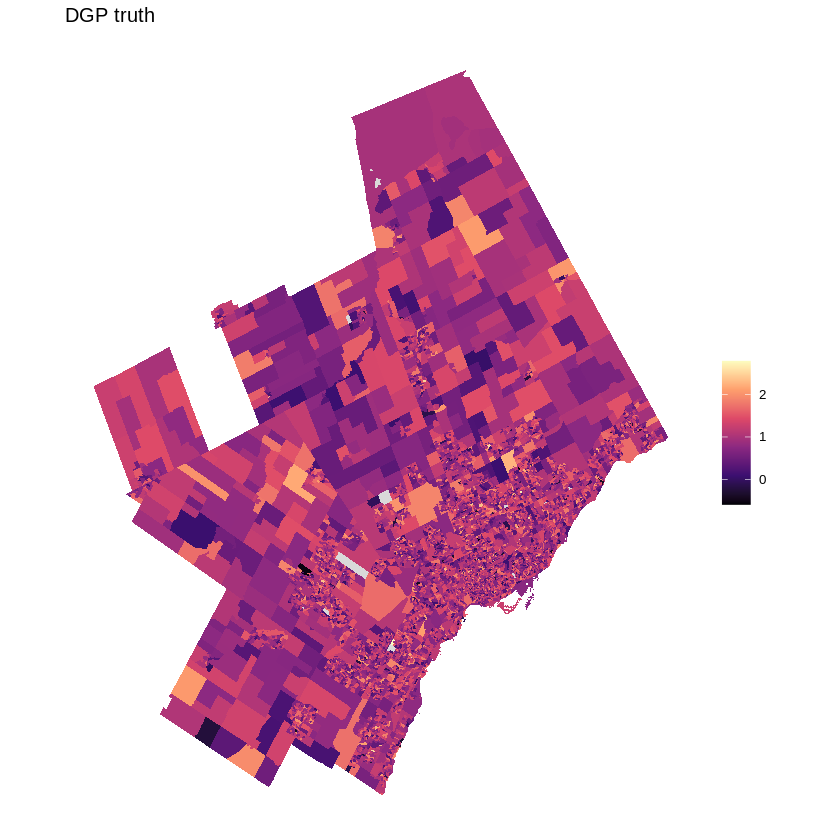

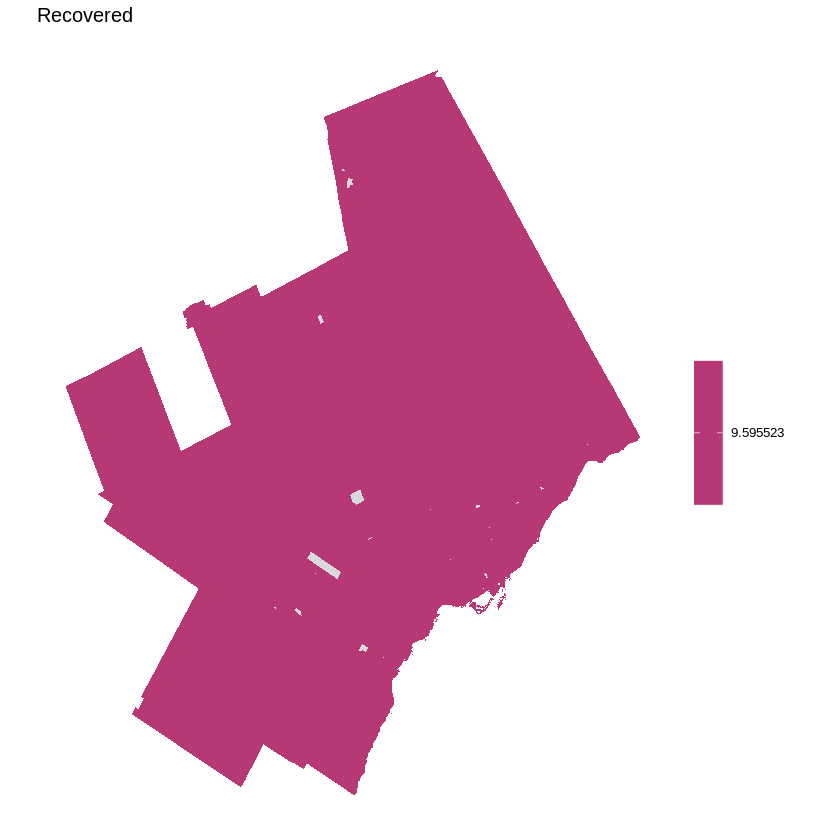

In [ ]:
ggsave("/content/before_truth.png",     p_truth, width = 6, height = 6, dpi = 130)
ggsave("/content/before_recovered.png", p_recov, width = 6, height = 6, dpi = 130)
cat("saved before_truth.png + before_recovered.png\n")
print(p_truth)
print(p_recov)

this is the before panel. truth panel = 1 + 0.4*F1 + 0.2*F3 on 7682 DAs, SD 0.447, range ~0-2.8. recovered = flat 9.60, all grey. Note that truth colours are iid rnorm draws - spread without spatial structure. this is not vuln geography, pre-patch DGP by design.

what patch adds is between-CMA structure (city-level offsets), not betwene-DA spatial pattern. within-city stays iid. estimator recovers the between-city slope not hot neighbourhoods.

Observations:
- coarse edges real (big suburban/rural DAs). grey silvers = 34 water/zero-pop unmatched. same tooling as Gasp (geom_sd + viridis); his showed real recovered structure ours can't yet.

geography for 3 new CMAs - Ottawa, Calgary, QC to N_CMA=6.

DGRF filter per CMA DGUID -> dedup DA -> join national da_all -> polygons. write shapefile bundles to DRive + st_bbox WGS84 per city.

dgrf + da_all are sec 1 objects. block checks exists first; if missing, reload section 1 before filter.

DGUIDs: Ottawa 2021S0503505, Calgary end is 825, QC end is 421.

pre: dgrf + da_all exist TRUE (if false, stop and reload 1)
- Ottawa ~2300 DAs (prefix 35 and 24 - bi-provicinial), Calgary ~2500 (48), Quebec ~1600 (24). missing 0 on join. boxes sane lon/lat per city.

In [ ]:
cat("dgrf exists:", exists("dgrf"), " da_all exists:", exists("da_all"), "\n")

if (exists("dgrf") && exists("da_all")) {
  new_dguids <- c(Ottawa   = "2021S0503505",
                  Calgary  = "2021S0503825",
                  Quebec   = "2021S0503421")

  new_da_lists <- lapply(new_dguids, function(dg) {
    db_rows <- dgrf[CMADGUID_RMRIDUGD == dg]
    dauids  <- substr(unique(db_rows$DADGUID_ADIDUGD), 10, 17)
    list(dauids = dauids)
  })

  new_polys <- lapply(names(new_da_lists), function(nm) {
    dauids <- new_da_lists[[nm]]$dauids
    poly   <- da_all[da_all$DAUID %in% dauids, ]
    list(poly = poly, n = nrow(poly),
         missing = length(setdiff(dauids, poly$DAUID)),
         prefixes = paste(sort(unique(substr(dauids, 1, 2))), collapse=","))
  })
  names(new_polys) <- names(new_da_lists)

  for (nm in names(new_polys)) {
    p <- new_polys[[nm]]
    poly <- p$poly; poly$DAUID <- as.character(poly$DAUID)
    out_dir <- sprintf("/content/%s_da_shp", tolower(nm))
    dir.create(out_dir, showWarnings = FALSE)
    st_write(poly["DAUID"], file.path(out_dir, sprintf("%s_da.shp", tolower(nm))),
             delete_dsn = TRUE, quiet = TRUE)
    zp <- sprintf("%s/%s_da_shp.zip", DRIVE, tolower(nm))
    if (file.exists(zp)) file.remove(zp)
    zip(zipfile = zp, files = list.files(out_dir, full.names = TRUE), flags = "-j")

    poly_wgs <- sf::st_transform(poly, 4326); bb <- sf::st_bbox(poly_wgs)  # bbox from polygons in WGS84 - hand-typed box clips edge DAs
    cat(sprintf("%-8s DAs:%5d  missing:%d  prefix:%-6s  bbox:[%.2f,%.2f,%.2f,%.2f]\n",
                nm, p$n, p$missing, p$prefixes,
                bb["xmin"]-0.05, bb["ymin"]-0.05, bb["xmax"]+0.05, bb["ymax"]+0.05))
  }
} else {
  cat("MISSING dgrf and/or da_all — reload §1.1 (national shapefile) + §1.2 (DGRF) before this block.\n")
}

dgrf exists: FALSE  da_all exists: FALSE 
MISSING dgrf and/or da_all — reload §1.1 (national shapefile) + §1.2 (DGRF) before this block.


reload section 1 national shapefile + DGRF from StatCan. re-download boundary zip + DGRF zips (they are permanent URLs), unzip, st_read national shp + fread DGRF> guarded file.exists.

pre
- da_all 57,932 rows, cols DAUID/DGUID/LANDAREA/PRUID/geom, no CMAUID,
- dgrf 498,786 rows x 16, DB-level
- if either short = download truncated, stop

In [ ]:
dir.create("/content/statcan", showWarnings = FALSE)

da_zip_url  <- "https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/boundary-limites/files-fichiers/lda_000b21a_e.zip"
da_zip_path <- "/content/statcan/da_boundaries.zip"
da_dir      <- "/content/statcan/da_extracted"
if (!file.exists(da_zip_path)) download.file(da_zip_url, da_zip_path, mode = "wb")
if (!dir.exists(da_dir)) { dir.create(da_dir); unzip(da_zip_path, exdir = da_dir) }

shp_path <- "/content/statcan/da_extracted/lda_000b21a_e.shp"
da_all <- sf::st_read(shp_path, quiet = TRUE) # national polygon set - all city joins hit this (short read/wrong CRS = silent corruption)
da_all$DAUID <- as.character(da_all$DAUID)

dgrf_zip_url  <- "https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/dguid-idugd/files-fichiers/2021_98260004.zip"
dgrf_zip_path <- "/content/statcan/dgrf.zip"
dgrf_dir      <- "/content/statcan/dgrf_extracted"
if (!file.exists(dgrf_zip_path)) download.file(dgrf_zip_url, dgrf_zip_path, mode = "wb")
if (!dir.exists(dgrf_dir)) { dir.create(dgrf_dir); unzip(dgrf_zip_path, exdir = dgrf_dir) }
dgrf <- data.table::fread("/content/statcan/dgrf_extracted/2021_98260004.csv")

cat("da_all rows:", nrow(da_all), " cols:", paste(colnames(da_all), collapse=","), "\n")
cat("CRS:", sf::st_crs(da_all)$input, "\n")
cat("dgrf rows:", nrow(dgrf), " cols:", ncol(dgrf), "\n")

da_all rows: 57932  cols: DAUID,DGUID,LANDAREA,PRUID,geometry 
CRS: NAD83 / Statistics Canada Lambert 
dgrf rows: 498786  cols: 16 


da_all rows: 57932  cols: DAUID,DGUID,LANDAREA,PRUID,geometry
CRS: NAD83 / Statistics Canada Lambert
dgrf rows: 498786  cols: 16  

---

section 1 reloaded. da_all 57,932 (national DA set), no CMAUID (shp knows prov only, need DGRF for CMA. CRS LAmbert. dgrf 498,786 x 16, DB-level.

rerun block with geography from earlier

In [ ]:
cat("dgrf exists:", exists("dgrf"), " da_all exists:", exists("da_all"), "\n")

if (exists("dgrf") && exists("da_all")) {
  new_dguids <- c(Ottawa   = "2021S0503505",
                  Calgary  = "2021S0503825",
                  Quebec   = "2021S0503421")

  new_da_lists <- lapply(new_dguids, function(dg) {
    db_rows <- dgrf[CMADGUID_RMRIDUGD == dg]
    dauids  <- substr(unique(db_rows$DADGUID_ADIDUGD), 10, 17)
    list(dauids = dauids)
  })

  new_polys <- lapply(names(new_da_lists), function(nm) {
    dauids <- new_da_lists[[nm]]$dauids
    poly   <- da_all[da_all$DAUID %in% dauids, ]
    list(poly = poly, n = nrow(poly),
         missing = length(setdiff(dauids, poly$DAUID)),
         prefixes = paste(sort(unique(substr(dauids, 1, 2))), collapse=","))
  })
  names(new_polys) <- names(new_da_lists)

  for (nm in names(new_polys)) {
    p <- new_polys[[nm]]
    poly <- p$poly; poly$DAUID <- as.character(poly$DAUID)
    out_dir <- sprintf("/content/%s_da_shp", tolower(nm))
    dir.create(out_dir, showWarnings = FALSE)
    st_write(poly["DAUID"], file.path(out_dir, sprintf("%s_da.shp", tolower(nm))),
             delete_dsn = TRUE, quiet = TRUE)
    zp <- sprintf("%s/%s_da_shp.zip", DRIVE, tolower(nm))
    if (file.exists(zp)) file.remove(zp)
    zip(zipfile = zp, files = list.files(out_dir, full.names = TRUE), flags = "-j")

    poly_wgs <- sf::st_transform(poly, 4326); bb <- sf::st_bbox(poly_wgs)  # bbox from polygons in WGS84 - hand-typed box clips edge DAs
    cat(sprintf("%-8s DAs:%5d  missing:%d  prefix:%-6s  bbox:[%.2f,%.2f,%.2f,%.2f]\n",
                nm, p$n, p$missing, p$prefixes,
                bb["xmin"]-0.05, bb["ymin"]-0.05, bb["xmax"]+0.05, bb["ymax"]+0.05))
  }
} else {
  cat("MISSING dgrf and/or da_all — reload §1.1 (national shapefile) + §1.2 (DGRF) before this block.\n")
}

dgrf exists: TRUE  da_all exists: TRUE 


Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 1: /content/ottawa_da_shp/ottawa_da.shp does not appear to be a file or directory.”


Ottawa   DAs: 2045  missing:0  prefix:24,35   bbox:[-76.69,44.80,-75.03,46.04]


Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 1: /content/calgary_da_shp/calgary_da.shp does not appear to be a file or directory.”


Calgary  DAs: 1898  missing:0  prefix:48      bbox:[-114.78,50.74,-113.33,51.54]


Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 1: /content/quebec_da_shp/quebec_da.shp does not appear to be a file or directory.”


Quebec   DAs: 1317  missing:0  prefix:24      bbox:[-71.86,46.48,-70.66,47.36]


In [ ]:
for (nm in c("ottawa","calgary","quebec")) {
  d  <- sprintf("/content/%s_da_shp", nm)
  zp <- sprintf("%s/%s_da_shp.zip", DRIVE, nm)
  files <- if (dir.exists(d)) list.files(d) else character(0)
  entries <- if (file.exists(zp)) nrow(unzip(zp, list = TRUE)) else NA
  cat(sprintf("%-8s dir_files:%d [%s]  zip_entries:%s\n",
              nm, length(files), paste(files, collapse=" "), entries))
}

ottawa   dir_files:4 [ottawa_da.dbf ottawa_da.prj ottawa_da.shp ottawa_da.shx]  zip_entries:4
calgary  dir_files:4 [calgary_da.dbf calgary_da.prj calgary_da.shp calgary_da.shx]  zip_entries:4
quebec   dir_files:4 [quebec_da.dbf quebec_da.prj quebec_da.shp quebec_da.shx]  zip_entries:4


dgrf exists: TRUE  da_all exists: TRUE
Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 1: /content/ottawa_da_shp/ottawa_da.shp does not appear to be a file or directory.”
Ottawa   DAs: 2045  missing:0  prefix:24,35   bbox:[-76.69,44.80,-75.03,46.04]
Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 1: /content/calgary_da_shp/calgary_da.shp does not appear to be a file or directory.”
Calgary  DAs: 1898  missing:0  prefix:48      bbox:[-114.78,50.74,-113.33,51.54]
Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 1: /content/quebec_da_shp/quebec_da.shp does not appear to be a file or directory.”
Quebec   DAs: 1317  missing:0  prefix:24      bbox:[-71.86,46.48,-70.66,47.36]

ottawa   dir_files:4 [ottawa_da.dbf ottawa_da.prj ottawa_da.shp ottawa_da.shx]  zip_entries:4
calgary  dir_files:4 [calgary_da.dbf calgary_da.prj calgary_da.shp calgary_da.shx]  zip_entries:4
quebec   dir_files:4 [quebec_da.dbf quebec_da.prj quebec_da.shp quebec_da.shx]  zi

---

3 new CMAs geography CLEAN! Ottawa 2045, Calgary 1898, Quebec 1317 DAs. missing 0 all. counts under BP approximates, boxes are also sane.

Ottawa prefix 24,35 = bi-provincial. Ottawa-Gat straddles the river: Ottawa=ON (35), Gat=QC(24), one CMA. Filtering on CMA DGUID catches both banks; province-filter would've halved it. DGUID-first was crucial.

Shop write threw GDAL warning but the bundles landed (4 entries each verified).